# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import torch
import torch.nn as nn
from torch.autograd import Variable
from torchinfo import summary
from tqdm import tqdm
from sklearn.metrics import r2_score

# Select device

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


# Problem Setup

In [3]:
a = 0.0 #start node
b = 1.0 #end node
Ne = 10 #elements

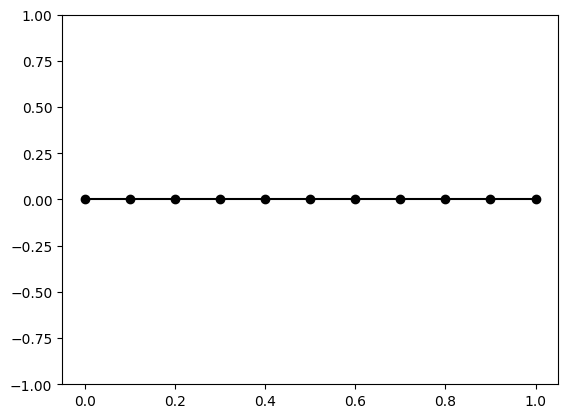

In [4]:
x = np.arange(0,b+(b-a)/Ne,1/Ne).reshape(-1,1) # x coordinates/ nodes for training
x_pred = np.arange(0,b+(b-a)/100,1/100).reshape(-1,1) # x coordinates for figure/ nodes for prediction
y = x*0

plt.figure()
plt.plot(x,y,'-k')
plt.plot(x,y,'ok')
plt.ylim([-1, 1])
plt.show()

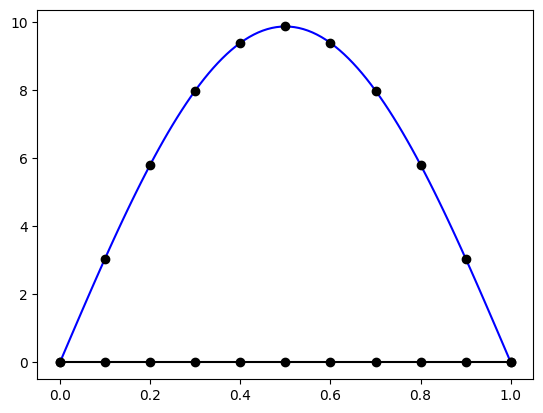

In [5]:
f_fun = math.pi**2*np.sin(math.pi*x) # body source
f_fun_fig = math.pi**2*np.sin(math.pi*x_pred) # body source for figure

plt.figure()
plt.plot(x,y,'-k')
plt.plot(x,y,'ok')
plt.plot(x_pred,f_fun_fig,'-b')
plt.plot(x,f_fun,'ok')
plt.show()

# Create Neural Net for training

# Activation function

In [6]:
class Tanh(nn.Module):
    def forward(self, x):
        return torch.tanh(x)

# Neural net definition

In [7]:
class create_net(nn.Module):
    def __init__(self):
        super(create_net, self).__init__()
        self.hidden_layer1 = nn.Linear(1,50)
        self.hidden_layer2 = nn.Linear(50,50)
        self.output_layer = nn.Linear(50,1)
        self.activation = Tanh()

    def forward(self, x):
        inputs = x
        layer1_out = self.hidden_layer1(inputs)
        layer1_out = self.activation(layer1_out)
        layer2_out = self.hidden_layer2(layer1_out)
        layer2_out = self.activation(layer2_out)     
        output = self.output_layer(layer2_out)
        return output

# Generate model

In [8]:
model = create_net()
model = model.to(device)
summary(model, x.shape)

Layer (type:depth-idx)                   Output Shape              Param #
create_net                               [11, 1]                   --
├─Linear: 1-1                            [11, 50]                  100
├─Tanh: 1-2                              [11, 50]                  --
├─Linear: 1-3                            [11, 50]                  2,550
├─Tanh: 1-4                              [11, 50]                  --
├─Linear: 1-5                            [11, 1]                   51
Total params: 2,701
Trainable params: 2,701
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.03
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.01
Estimated Total Size (MB): 0.02

# Create Loss function for training

# PDE residual definition

In [9]:
def PDE_residual(x, model, f):
    u = model(x)
    dudx = torch.autograd.grad(u.sum(), x, create_graph=True)[0]
    d2udx2 = torch.autograd.grad(dudx.sum(), x, create_graph=True)[0]
    
    res = -d2udx2-f
    
    return res  

# Convert variables to tensors for training

In [10]:
x_ode = Variable(torch.from_numpy(x).float(), requires_grad=True).to(device)
f_fun_ode = Variable(torch.from_numpy(f_fun).float(), requires_grad=True).to(device)
a_ode = Variable(torch.tensor(a)*torch.ones((1,1)), requires_grad=True).to(device)
b_ode = Variable(torch.tensor(b)*torch.ones((1,1)), requires_grad=True).to(device)
BC_l = Variable(torch.zeros((1,1)), requires_grad=True).to(device)
BC_r = Variable(torch.zeros((1,1)), requires_grad=True).to(device)

# Loss function definition

In [11]:
def loss(x, model, f, a, b, BC_l, BC_r):
        
    u_bc_l = model(a)
    
    u_bc_r = model(b)
    
    res = PDE_residual(x, model, f)
    
    loss = torch.nn.MSELoss()
    
    zero_vec = torch.zeros(res.shape).to(device)
    
    BC_loss = loss(u_bc_l, BC_l) + loss(u_bc_r, BC_r)
    
    PDE_loss = loss(res, zero_vec)
    
    total_loss = torch.tensor(1.0).to(device)*BC_loss + torch.tensor(1.0).to(device)*PDE_loss

    return BC_loss, PDE_loss, total_loss

# Training step

# Select number of epochs (iterations) and optimizer

In [12]:
epochs = 100
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)
pbar = tqdm(range(epochs), desc='description')

description:   0%|          | 0/100 [00:00<?, ?it/s]

# Back propagation definition

In [13]:
def closure():
    if torch.is_grad_enabled():
        optimizer.zero_grad()
    
    _, _, total_loss = loss(x_ode, model, f_fun_ode, a_ode, b_ode, BC_l, BC_r)
    
    if total_loss.requires_grad:
        total_loss.backward()
    
    return total_loss

# Run training

In [14]:
for i in pbar:
    
    optimizer.step(closure)
    
    BC_loss, PDE_loss, total_loss = loss(x_ode, model, f_fun_ode, a_ode, b_ode, BC_l, BC_r)
    
    pbar.set_description("BC_loss: %.2e | PDE_loss: %.2e | total_loss: %.2e " % (BC_loss.cpu().detach().numpy(), PDE_loss.cpu().detach().numpy(), total_loss.cpu().detach().numpy()))

BC_loss: 8.65e-05 | PDE_loss: 2.79e-03 | total_loss: 2.88e-03 : 100%|██████████| 100/100 [00:00<00:00, 121.45it/s]


# Compare to actual

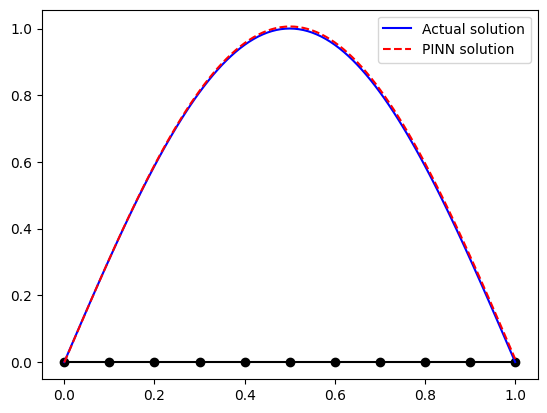

In [15]:
x_pred_ode = Variable(torch.from_numpy(x_pred).float(), requires_grad=True).to(device)

with torch.no_grad():
    u_pred = model(x_pred_ode)
    
u_actual = np.sin(math.pi*x_pred)

plt.figure()
plt.plot(x,y,'-k')
plt.plot(x,y,'ok')
plt.plot(x_pred,u_actual,'-b', label='Actual solution')
plt.plot(x_pred,u_pred.cpu().numpy(),'--r', label='PINN solution')
plt.legend()
plt.show()

In [16]:
r2_score(u_pred.cpu().numpy(), u_actual)

0.9995948659636138